In [24]:
from pathlib import Path
import os
import subprocess
import sys

REPO_NAME = "CS-171-Chest-X-Ray-Medical-Diagnosis"
REPO_URL = "https://github.com/jenilkathrotia/CS-171-Chest-X-Ray-Medical-Diagnosis.git"
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    colab_repo = Path("/content") / REPO_NAME
    if not colab_repo.exists():
        subprocess.run(["git", "clone", REPO_URL, str(colab_repo)], check=True)
    os.chdir(colab_repo)


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate

    colab_candidate = Path("/content") / REPO_NAME
    if (colab_candidate / "src").exists():
        return colab_candidate

    raise FileNotFoundError(
        f"Could not locate project root from cwd={start}. Expected a directory containing src/ and notebooks/."
    )


cwd = Path.cwd()
project_root = resolve_project_root(cwd)
src_path = project_root / "src"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

if IS_COLAB and (project_root / "requirements.txt").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(project_root / "requirements.txt")],
        check=False,
    )

print("cwd:", cwd)
print("project_root:", project_root)
print("src exists:", src_path.exists())

import kagglehub

In [25]:
raw_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

candidate_paths = [
    Path(raw_path) / "chest_xray",
    Path(raw_path),
]

base = next(
    (
        str(path)
        for path in candidate_paths
        if (path / "train").exists() and (path / "val").exists() and (path / "test").exists()
    ),
    None,
)

if base is None:
    raise FileNotFoundError(
        f"Could not find dataset splits under {raw_path}. Expected train/ val/ test/ directories."
    )

print("kagglehub root:", raw_path)
print("DATA_DIR:", base)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray


In [26]:
print(os.listdir(base))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [27]:
def count_images(split):
    split_path = os.path.join(base, split)
    counts = {}

    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = os.path.join(split_path, cls)
        counts[cls] = len(os.listdir(cls_path))

    return counts


train_counts = count_images("train")
val_counts = count_images("val")
test_counts = count_images("test")

print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Val: {'NORMAL': 8, 'PNEUMONIA': 8}
Test: {'NORMAL': 234, 'PNEUMONIA': 390}


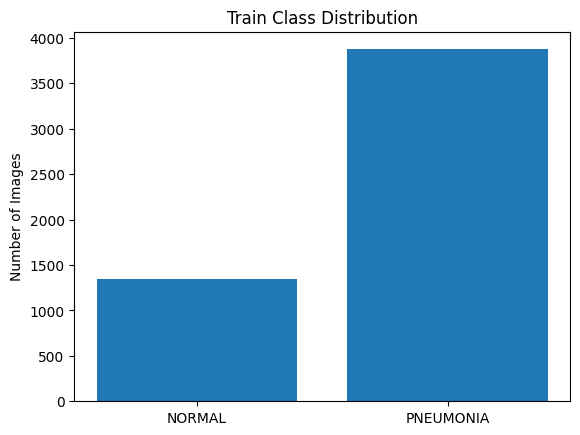

In [28]:
import matplotlib.pyplot as plt

labels = list(train_counts.keys())
values = list(train_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Train Class Distribution")
plt.ylabel("Number of Images")
plt.show()

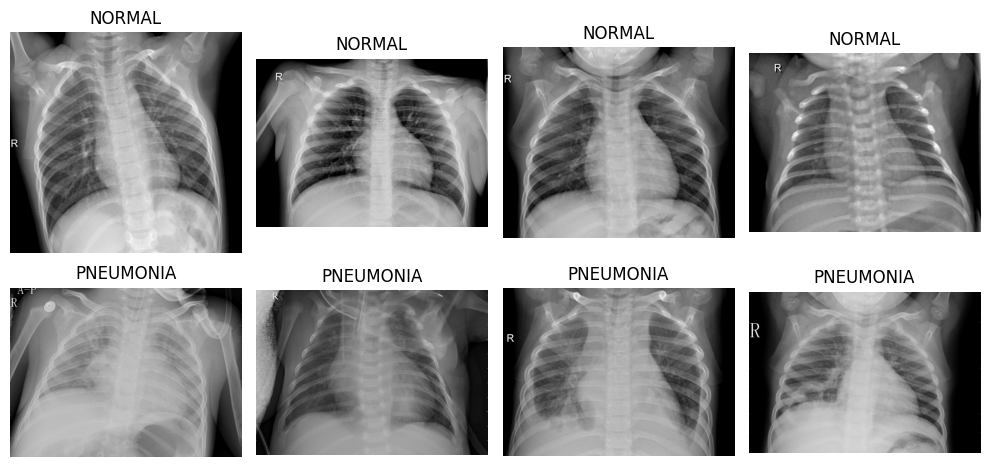

In [29]:
import random
from PIL import Image

def show_samples(class_name, n=4):
    folder = os.path.join(base, "train", class_name)
    files = random.sample(os.listdir(folder), n)
    return [Image.open(os.path.join(folder, f)) for f in files]


normal_imgs = show_samples("NORMAL", 4)
pneumonia_imgs = show_samples("PNEUMONIA", 4)

plt.figure(figsize=(10,5))

for i, img in enumerate(normal_imgs + pneumonia_imgs):
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL" if i < 4 else "PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

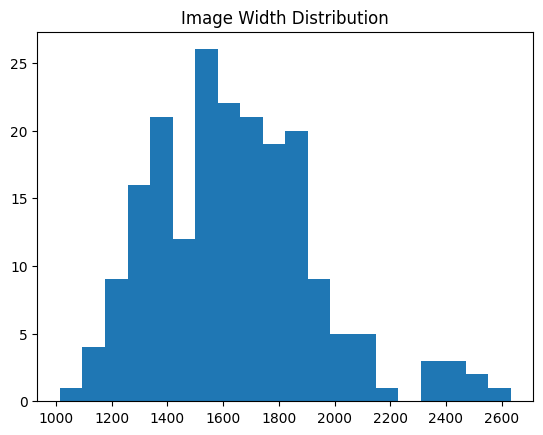

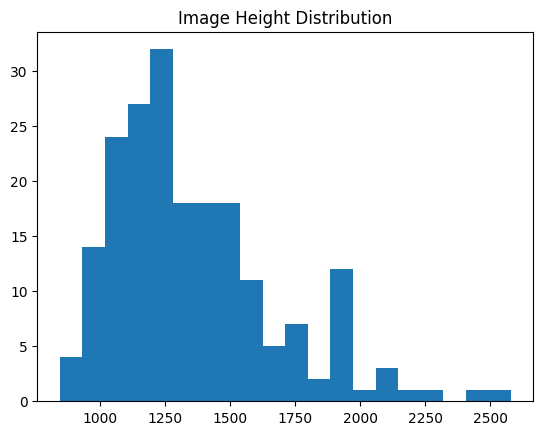

In [30]:
import numpy as np

widths = []
heights = []

sample_dir = os.path.join(base, "train", "NORMAL")
files = os.listdir(sample_dir)[:200]

for f in files:
    img = Image.open(os.path.join(sample_dir, f))
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure()
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

plt.figure()
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

In [31]:
normal = train_counts["NORMAL"]
pneumonia = train_counts["PNEUMONIA"]

ratio = pneumonia / normal

print("NORMAL:", normal)
print("PNEUMONIA:", pneumonia)
print("Pneumonia-to-Normal ratio:", round(ratio, 2))

NORMAL: 1341
PNEUMONIA: 3875
Pneumonia-to-Normal ratio: 2.89


In [21]:
print("Path bootstrap already configured above.")
print("cwd:", cwd)
print("project_root:", project_root)
print("src_path:", src_path)

FileNotFoundError: Could not find src directory from cwd=/content or cwd.parent=/

In [ ]:
import os
print(os.listdir(project_root))

['run', 'proc', 'tmp', 'sbin', 'var', 'lib32', 'libx32', 'bin', 'srv', 'media', 'home', 'usr', 'dev', 'lib64', 'lib', 'sys', 'etc', 'root', 'opt', 'boot', 'mnt', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']


In [22]:
print(os.listdir(src_path))

FileNotFoundError: [Errno 2] No such file or directory: '/src'

In [ ]:
from src.datasets import get_dataloaders
print("import worked")

import worked


In [18]:
from src.datasets import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(base)

print(len(train_loader), len(val_loader), len(test_loader))

163 1 20
